In [1]:
import numpy as np


def gauss_2(a, b):
    r"""Return nodes and weights for a two-point Gauss quadrature on [a, b].
    
    Parameters
    ----------
    a, b : float
       Boundaries of the integration interval
       
    Returns
    -------
    x1, x2, w1, w2 : float
       Nodes and weights of the quadrature.
    """
    midpoint = (a + b) / 2
    half_length = (b - a) / 2
    
    t1 = -1 / (3 ** 0.5)
    t2 = 1 / (3 ** 0.5)
    
    x1 = midpoint + half_length * t1
    x2 = midpoint + half_length * t2
    
    w1 = half_length
    w2 = half_length
    
    return x1, x2, w1, w2

from numpy.testing import assert_allclose

x1, x2, w1, w2 = gauss_2(0, 1)

def f(x, n): 
    return x**n

for n in [0, 1, 2, 3]:
    assert_allclose(w1*f(x1, n=n) + w2*f(x2, n=n),
                    1./(n+1), atol=1e-14)

Исходный интеграл:
$$I = \int_{0}^{1} \frac{e^x}{\sqrt{x(1-x)}} \, dx$$

Вычтем линейную функцию \(a + bx\), подобранную так, чтобы она совпадала с $e^x$ в точках x=0 и x=1:

В точке x=0: $a + b\cdot 0 = e^0 = 1 \Rightarrow a = 1$
В точке x=1: $a + b\cdot 1 = e^1 = e \Rightarrow 1 + b = e \Rightarrow b = e-1$

Таким образом, $a + bx = 1 + (e-1)x$.

Тогда:
$$\frac{e^x}{\sqrt{x(1-x)}} = \frac{1 + (e-1)x}{\sqrt{x(1-x)}} + \frac{e^x - [1 + (e-1)x]}{\sqrt{x(1-x)}}$$

Интеграл от первого слагаемого вычисляется аналитически:
$$\int_{0}^{1} \frac{1 + (e-1)x}{\sqrt{x(1-x)}} \, dx = \int_{0}^{1} \frac{1}{\sqrt{x(1-x)}} \, dx + (e-1)\int_{0}^{1} \frac{x}{\sqrt{x(1-x)}} \, dx = \pi + (e-1)\frac{\pi}{2} = \pi\left(1 + \frac{e-1}{2}\right)$$

Второе слагаемое не имеет особенностей, так как:
$$\lim_{x\to 0}\frac{e^x - [1 + (e-1)x]}{\sqrt{x(1-x)}} = 0, \quad \lim_{x\to 1}\frac{e^x - [1 + (e-1)x]}{\sqrt{x(1-x)}} = 0$$
(числитель имеет второй порядок малости вблизи концов, знаменатель - первый порядок)

Поэтому интеграл можно представить как:
$$I = \pi\left(1 + \frac{e-1}{2}\right) + \int_{0}^{1} \frac{e^x - 1 - (e-1)x}{\sqrt{x(1-x)}} \, dx$$

где второй интеграл вычисляется численно методом трапеций.

In [2]:
def integ(npts=10):
    """Compute the value of the integral above.
    
    Subtract the singularities and use the trapezoid rule. 
    
    Parameters
    ----------
    npts : int
        The number of points for the trapezoid rule
        
    Returns
    -------
    I : float
       The computed value of the integral
    """
    e = np.exp(1)
    analytic_part = np.pi * (1 + (e - 1) / 2)
    
    x = np.linspace(0, 1, npts)
    h = x[1] - x[0]
    
    def regular_f(x):
        if x == 0 or x == 1:
            return 0  
        numerator = np.exp(x) - (1 + (e - 1) * x)
        denominator = np.sqrt(x * (1 - x))
        return numerator / denominator
    
    y = np.array([regular_f(xi) for xi in x])
    
    numerical_part = h * (np.sum(y[1:-1]) + (y[0] + y[-1]) / 2)
    
    return analytic_part + numerical_part

def check_runge(npts=10):
    I_h = integ(npts)
    I_h2 = integ(npts*2)
    
    error_estimate = abs(I_h2 - I_h) / 3
    
    return I_h2, error_estimate

I, error = check_runge(100)
I, error

(np.float64(5.508556973198514), np.float64(7.839078235634862e-05))

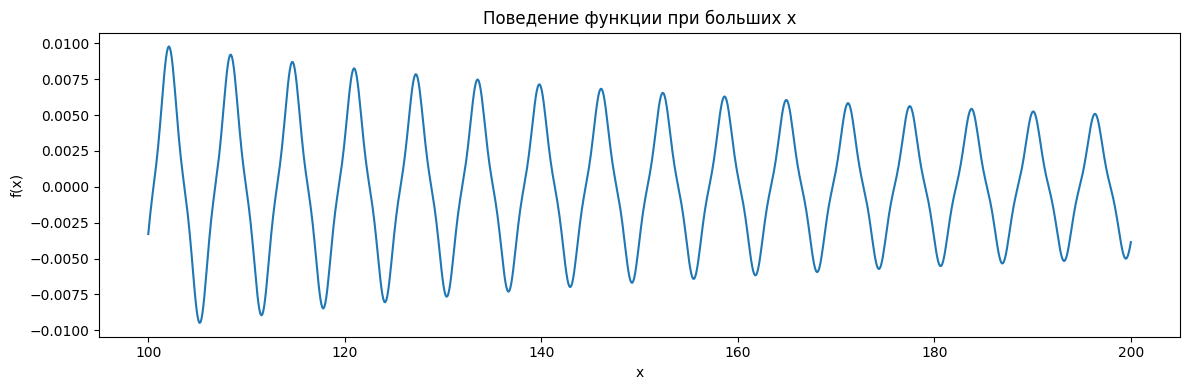

C:\Users\user\AppData\Local\Temp\ipykernel_17736\3342489261.py:21: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, error = quad(f, 0, 10000)
C:\Users\user\AppData\Local\Temp\ipykernel_17736\3342489261.py:30: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(f, 0, x_max, limit=200)
C:\Users\user\AppData\Local\Temp\ipykernel_17736\3342489261.py:30: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  val, _ = quad(f, 0, x_max, limit=200)



Интеграл до 10000: 0.815979 ± 1.496097


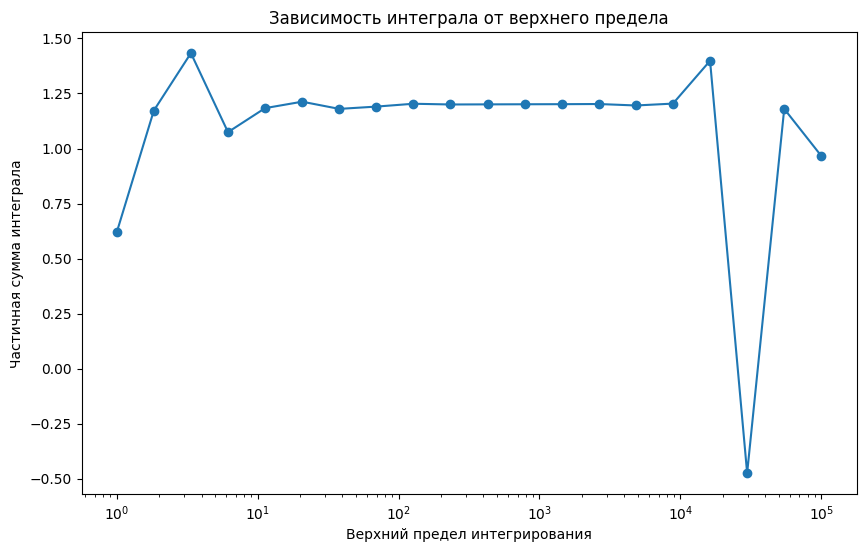

In [20]:
from scipy.integrate import quad
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x) * np.cos(np.cos(x)) / x

x_large = np.linspace(100, 200, 1000)
y_large = f(x_large)

plt.figure(figsize=(12, 4))

plt.subplot(1, 1, 1)
plt.plot(x_large, y_large)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Поведение функции при больших x')
plt.tight_layout()
plt.show()

try:
    result, error = quad(f, 0, 10000)
    print(f"\nИнтеграл до 10000: {result:.6f} ± {error:.6f}")
except Exception as e:
    print(e)

x_points = np.logspace(0, 5, 20)
partial_integrals = []

for x_max in x_points:
    val, _ = quad(f, 0, x_max, limit=200)
    partial_integrals.append(val)

plt.figure(figsize=(10, 6))
plt.semilogx(x_points, partial_integrals, 'o-')
plt.xlabel('Верхний предел интегрирования')
plt.ylabel('Частичная сумма интеграла')
plt.title('Зависимость интеграла от верхнего предела')
plt.show()

Рассмотрим интеграл
$$
J = \int_{-0.5}^{0.5} |x|^{-1/2} (1 - x)^{-1/2} \, dx.
$$
Особенность только в точке $x = 0$. Выберем одинаковые $\delta_1 = \delta_2 = \delta$ (так зануляется первая степень в разложении функции вблизи нуля)

Разложим $(1 - x)^{-1/2}$ в ряд вблизи $x = 0$:
$$
(1 - x)^{-1/2} = 1 + \frac{x}{2} + \frac{3x^2}{8} + O(x^3).
$$

Тогда подынтегральная функция:
$$
f(x) = |x|^{-1/2} \left(1 + \frac{x}{2} + \frac{3x^2}{8} + \dots\right).
$$

Вычтем сингулярную часть $|x|^{-1/2}$ на $[-\delta, \delta]$. Ошибка отбрасывания:
$$
\rho = \int_{-\delta}^{\delta} |x|^{-1/2} \left( \frac{x}{2} + \frac{3x^2}{8} + \dots \right) dx.
$$

Член с $x/2$ даёт нулевой вклад из-за нечётности. Главный вклад от $3x^2/8$:
$$
\rho \approx \frac{3}{8} \int_{-\delta}^{\delta} |x|^{-1/2} x^2 dx = \frac{3}{4} \int_0^{\delta} x^{3/2} dx = \frac{3}{4} \cdot \frac{2}{5} \delta^{5/2} = \frac{3}{10} \delta^{5/2}.
$$

Условие $|\rho| < \varepsilon$ даёт:
$$
\frac{3}{10} \delta^{5/2} < \varepsilon \quad \Rightarrow \quad \delta < \left( \frac{10\varepsilon}{3} \right)^{2/5}.
$$


In [ ]:
from scipy.integrate import simpson
from numpy.polynomial import Polynomial

def exact_integral(k):
    return k/(1 + k**2) - np.exp(-np.pi)*(k*np.cos(k*np.pi) + np.sin(k*np.pi))/(1 + k**2)

def f(x, k):
    return np.exp(-x) * np.sin(k * x)

def simpson_method(k, n):
    x = np.linspace(0, np.pi, n)
    y = f(x, k)
    return simpson(y, x=x)

def poly_method(k, n, degree):
    x = np.linspace(0, np.pi, n)
    
    p = Polynomial.fit(x, np.exp(-x), degree)
    
    int_phi = simpson(p(x) * np.sin(k*x), x=x)
    int_diff = simpson((np.exp(-x) - p(x)) * np.sin(k*x), x=x)
    
    return int_phi + int_diff

k_values = [100, 500, 1000]
n_points = 10000

print("k\tТочное\t\tСимпсон\t\tПолином2\tПолином3")
print("-" * 80)

for k in k_values:
    exact = exact_integral(k)
    simp = simpson_method(k, n_points)
    poly2 = poly_method(k, n_points, 2)
    poly3 = poly_method(k, n_points, 3)
    
    print(f"{k}\t{exact:.8f}\t{simp:.8f}\t{poly2:.8f}\t{poly3:.8f}")
    print(f"\t\t\t{abs(simp-exact):.2e}\t{abs(poly2-exact):.2e}\t{abs(poly3-exact):.2e}")
    print()

k	Точное		Симпсон		Полином2	Полином3
--------------------------------------------------------------------------------
100	0.00956690	0.00956690	0.00956690	0.00956690
			3.42e-11	3.42e-11	3.42e-11

500	0.00191356	0.00191357	0.00191357	0.00191357
			4.32e-09	4.32e-09	4.32e-09

1000	0.00095679	0.00095682	0.00095682	0.00095682
			3.57e-08	3.57e-08	3.57e-08

